# 27 III 2025

In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import toolkit
import pickle

In [2]:
with open("data/train.pkl", "rb") as file:
    X_train = pickle.load(file).reset_index()

In [3]:
toolkit.replace(X_train)

,index,Status,Message
0,2870,0,From ilug-admin@linux.ie Thu Aug 29 16:42:34 ...
1,13153,0,From rssfeeds@jmason.org Thu Sep 26 16:43:26 ...
2,4278,0,From spamassassin-talk-admin@lists.sourceforge...
3,4038,2,From jm@netnoteinc.com Mon Jul 29 11:22:06 20...
4,774,0,From fork-admin@xent.com Mon Sep 23 15:00:49 ...
...,...,...,...
10623,11817,0,From fork-admin@xent.com Fri Sep 20 16:15:28 ...
10624,1234,2,From marninainj@chel.elektra.ru Fri Sep 6 11...
10625,7579,0,From fork-admin@xent.com Fri Sep 13 13:37:27 ...
10626,3600,0,From fork-admin@xent.com Mon Sep 23 23:45:34 ...


In [4]:
X_train.loc[1, "Message"]

"From rssfeeds@jmason.org  Thu Sep 26 16:43:26 2002 .Return-Path: <rssfeeds@spamassassin.taint.org> .Delivered-To: yyyy@localhost.spamassassin.taint.org .Received: from localhost (jalapeno [127.0.0.1]) .\tby jmason.org (Postfix) with ESMTP id E080E16F76 .\tfor <jm@localhost>; Thu  26 Sep 2002 16:42:30 +0100 (IST) .Received: from jalapeno [127.0.0.1] .\tby localhost with IMAP (fetchmail-5.9.0) .\tfor jm@localhost (single-drop); Thu  26 Sep 2002 16:42:30 +0100 (IST) .Received: from dogma.slashnull.org (localhost [127.0.0.1]) by .    dogma.slashnull.org (8.11.6/8.11.6) with ESMTP id g8QFSsg24511 for .    <jm@jmason.org>; Thu  26 Sep 2002 16:28:54 +0100 .Message-Id: <200209261528.g8QFSsg24511@dogma.slashnull.org> .To: yyyy@spamassassin.taint.org .From: fark <rssfeeds@spamassassin.taint.org> .Subject: Friends don't let friends swim drunk. Paging Dr. Darwin.. .Date: Thu  26 Sep 2002 15:28:54 -0000 .Content-Type: text/plain; encoding=utf-8 . .URL: http://www.newsisfree.com/click/-4 8272607 17

In [5]:
X_train_spam = X_train[X_train["Status"] == 2]
X_train_ham = X_train[X_train["Status"]  < 2]

In [6]:
spam_words = dict()
ham_words = dict()
counter_spam = 0
for index, row in X_train_spam.iterrows():
    #print(row)
    x = pd.Series(row["Message"].split(" "))
    x = x[x != ""]
    x = x.value_counts()
    for (word, count) in x.to_dict().items():
        if word in spam_words.keys():
            spam_words[word] = spam_words[word] + count
        else:
            spam_words[word] = count

    counter_spam += 1

In [7]:
counter_ham = 0
for index, row in X_train_ham.iterrows():
    #print(row)
    x = pd.Series(row["Message"].split(" "))
    x = x[x != ""]
    x = x.value_counts()
    for (word, count) in x.to_dict().items():
        if word in ham_words.keys():
            ham_words[word] = ham_words[word] + count
        else:
            ham_words[word] = count

    counter_ham += 1

In [8]:
ham_words["total_count"] = counter_ham
spam_words["total_count"] = counter_spam

In [9]:
with open("ham_training_word_dictionary.pkl", "wb") as file:
    pickle.dump(ham_words, file)

In [10]:
with open("spam_training_word_dictionary.pkl", "wb") as file:
    pickle.dump(spam_words, file)

## Analysis

In [11]:
ham_words = pd.Series(ham_words)
spam_words = pd.Series(spam_words)

In [12]:
threshold = 0.1
ham_words = ham_words[ham_words > threshold*counter_ham]
spam_words = spam_words[spam_words > threshold*counter_spam]

In [13]:
ham_words.sort_values(ascending=False)[:20]/counter_ham

.             30.039283
the            9.916008
2002           8.649522
with           6.809484
to             6.706736
from           6.691282
.>             6.217884
.Received:     5.816209
of             5.425268
a              4.962841
and            4.879792
for            4.842987
by             4.601982
id             4.317329
ESMTP          3.288428
in             3.209036
Sep            3.056860
+0100          2.997051
is             2.988793
Aug            2.545358
dtype: float64

In [14]:
spam_words.sort_values(ascending=False)[:20]/counter_spam

.             46.961413
the            8.823803
to             8.461646
2002           6.523942
and            6.496048
with           5.835890
of             5.794979
from           5.767085
you            4.907020
for            4.834031
.Received:     4.391446
a              4.387262
=              4.324965
by             3.520223
in             3.408647
;              3.398884
your           3.388656
id             3.206881
is             3.053464
<td            2.490005
dtype: float64

In [15]:
ham_words.name = "count_ham"
spam_words.name = "count_spam"

In [16]:
ham_words = ham_words / counter_ham
spam_words = spam_words / counter_spam

In [17]:
comparison = pd.DataFrame(ham_words).reset_index(names="word")\
.merge(pd.DataFrame(spam_words).reset_index(names="word"), on="word")

In [18]:
comparison.head()

,word,count_ham,count_spam
0,.,30.039283,46.961413
1,.>,6.217884,0.148768
2,29,0.287956,0.283124
3,Aug,2.545358,1.527662
4,2002,8.649522,6.523942


In [19]:
comparison.shape

(317, 3)

In [20]:
higher_in_ham = comparison.loc[
        comparison["count_ham"] > comparison["count_spam"],
        "word"
]

In [21]:
higher_in_spam = comparison.loc[
        comparison["count_ham"] < comparison["count_spam"],
        "word"
]

In [22]:
higher_in_ham.shape, higher_in_spam.shape

((164,), (152,))

In [23]:
comparison.sort_values("count_ham", ascending=False)

,word,count_ham,count_spam
0,.,30.039283,46.961413
5,the,9.916008,8.823803
4,2002,8.649522,6.523942
7,with,6.809484,5.835890
23,to,6.706736,8.461646
...,...,...,...
161,e-mail,0.101923,0.303115
91,Produced,0.101333,0.106927
270,send,0.100979,0.419805
232,give,0.100625,0.145979


In [24]:
comparison[(comparison["count_ham"] > 1) | (comparison["count_spam"] > 1)].sort_values("count_ham", ascending=False).reset_index(drop=True)

,word,count_ham,count_spam
0,.,30.039283,46.961413
1,the,9.916008,8.823803
2,2002,8.649522,6.523942
3,with,6.809484,5.835890
4,to,6.706736,8.461646
...,...,...,...
61,.mv,0.459832,1.114830
62,our,0.341512,1.362622
63,<td,0.319453,2.490005
64,Helvetica,0.165507,1.603440


In [25]:
frequent = comparison[(comparison["count_ham"] > 1) | (comparison["count_spam"] > 1)].sort_values("count_ham", ascending=False).reset_index(drop=True)

In [26]:
frequent[frequent["word"] == "Fri"], frequent[frequent["word"] == "Mon"]

(   word  count_ham  count_spam
 49  Fri    1.04872    0.751278,
    word  count_ham  count_spam
 29  Mon   1.572018    1.383078)

In [27]:
frequent[frequent["word"] == "Wed"]

,word,count_ham,count_spam
32,Wed,1.514923,0.973036


In [28]:
list(frequent["word"])

['.',
 'the',
 '2002',
 'with',
 'to',
 'from',
 '.>',
 '.Received:',
 'of',
 'a',
 'and',
 'for',
 'by',
 'id',
 'ESMTP',
 'in',
 'Sep',
 '+0100',
 'is',
 'Aug',
 'that',
 'localhost',
 'I',
 '.\tby',
 '.\tfor',
 '[127.0.0.1])',
 '(Postfix)',
 'on',
 'it',
 'Mon',
 'be',
 '(IST)',
 'Wed',
 'Thu',
 '>',
 'you',
 '.Delivered-To:',
 'Tue',
 '-0700',
 '(8.11.6/8.11.6)',
 'this',
 '-0400',
 'dogma.slashnull.org',
 '.Date:',
 'are',
 'have',
 'as',
 '(localhost',
 '.From:',
 'Fri',
 '.Subject:',
 '.To:',
 'not',
 'Jul',
 '.Content-Type:',
 'or',
 '-',
 'your',
 'can',
 'will',
 '=',
 '.mv',
 'our',
 '<td',
 'Helvetica',
 '</tr>']

### Examining words frequent in spam and absent in ham

In [29]:
df = pd.DataFrame(spam_words).reset_index(names="word").merge(pd.DataFrame(ham_words).reset_index(names="word"), how="left")

In [30]:
df = df[df["count_ham"].isna()].drop("count_ham", axis=1)

In [31]:
df.sort_values("count_spam", ascending=False)

,word,count_spam
581,;,3.398884
330,"sans-serif""",0.968387
590,</td>,0.958624
328,Arial,0.917713
407,<tr>,0.839609
...,...,...
409,computer,0.100418
461,ALL,0.100418
505,purchase,0.100418
503,total,0.100418


In [32]:
spam_words_df = pd.DataFrame(spam_words).reset_index(names="word")

In [33]:
spam_words_ = spam_words_df[(spam_words_df["word"].str.find(">")>0) | (spam_words_df["word"].str.find("<")>0)]

In [34]:
spam_words_.shape

(69, 2)

In [35]:
spam_words_['count_spam'].sum()

np.float64(19.696885169688517)

In [36]:
ham_words_df = pd.DataFrame(ham_words).reset_index(names="word")

In [37]:
ham_words_df_ = ham_words_df[(ham_words_df["word"].str.find(">")>0) | (ham_words_df["word"].str.find("<")>0) ]

In [38]:
ham_words_df_.shape

(41, 2)

In [39]:
ham_words_df_['count_ham'].sum()

np.float64(16.58334316385514)

Na szczególną uwagę zasługują także < oraz >

In [40]:
df = ham_words_df.merge(spam_words_df, how="left")

In [41]:
df = df[df['count_spam'].isna()]

In [42]:
df.sort_values("count_ham", ascending=False)

,word,count_ham,count_spam
265,Oct,1.658842,NaN
141,.\t,0.814557,NaN
165,.List-Unsubscribe:,0.634069,NaN
163,.List-Subscribe:,0.607526,NaN
161,.List-Help:,0.601038,NaN
...,...,...,...
370,width=10,0.101333,NaN
505,It's,0.100507,NaN
304,05,0.100507,NaN
222,.In,0.100389,NaN


There's nothing special about words present in one category and absent in the other, so we'll focus on the words present in both of them. Let's plot some histograms to reveale distributions.

## Distributions of words' counts

In [43]:
comparison.head()

,word,count_ham,count_spam
0,.,30.039283,46.961413
1,.>,6.217884,0.148768
2,29,0.287956,0.283124
3,Aug,2.545358,1.527662
4,2002,8.649522,6.523942


In [44]:
comparison.shape

(317, 3)

In [45]:
df = comparison[["word"]]

In [46]:
df["count"] = 0

C:\Users\User\AppData\Local\Temp\ipykernel_17264\1395553266.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["count"] = 0


In [47]:
df

,word,count
0,.,0
1,.>,0
2,29,0
3,Aug,0
4,2002,0
...,...,...
312,28,0
313,21,0
314,<TD,0
315,.mv,0


In [48]:
statring_dict = df.set_index("word").to_dict()

In [49]:
ham_series = []

for index, row in X_train_ham.iterrows():
    x = pd.Series(row["Message"].split(" "))
    x = x[x != ""]
    ham_series.append(x.value_counts())

In [50]:
for i in range(len(ham_series)):
    ham_series[i].name = str(i+1)
    ham_series[i] = pd.DataFrame(ham_series[i]).reset_index(names="word")

In [51]:
df.drop("count", inplace=True, axis=1)

C:\Users\User\AppData\Local\Temp\ipykernel_17264\3550670779.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop("count", inplace=True, axis=1)


In [52]:
df.merge(ham_series[0], how="left")

,word,1
0,.,20.0
1,.>,14.0
2,29,9.0
3,Aug,9.0
4,2002,9.0
...,...,...
312,28,NaN
313,21,NaN
314,<TD,NaN
315,.mv,NaN


In [53]:
df_ = df
for series in ham_series:
    df_ = df_.merge(series, how="left", on="word")

In [54]:
df_.shape

(317, 8478)

In [55]:
X_train_ham.shape

(8477, 3)

In [56]:
df_ = df_.set_index("word").T

In [57]:
df_.shape

(8477, 317)

In [58]:
with open("ham_important_words_df.pkl", "wb") as file:
    pickle.dump(df_, file)

In [59]:
spam_series = []

for index, row in X_train_spam.iterrows():
    x = pd.Series(row["Message"].split(" "))
    x = x[x != ""]
    spam_series.append(x.value_counts())

In [60]:
for i in range(len(spam_series)):
    spam_series[i].name = str(i+1)
    spam_series[i] = pd.DataFrame(spam_series[i]).reset_index(names="word")

In [61]:
df_ = df
for series in spam_series:
    df_ = df_.merge(series, how="left", on="word")

In [62]:
with open("spam_important_words_df.pkl", "wb") as file:
    pickle.dump(df_.set_index("word").T, file)

In [63]:
with open("spam_important_words_df.pkl", "rb") as file:
    z = pickle.load(file)

In [64]:
z.shape

(2151, 317)

In [65]:
with open("ham_important_words_df.pkl", "rb") as file:
    z = pickle.load(file)
z.shape

(8477, 317)

# 28 III 2025

In [66]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import toolkit

In [70]:
with open("spam_important_words_df.pkl", "rb") as file:
    spam_words_count = pickle.load(file)

In [71]:
with open("ham_important_words_df.pkl", "rb") as file:
    ham_words_count = pickle.load(file)

In [72]:
spam_words_count.shape, ham_words_count.shape

((2151, 317), (8477, 317))

In [73]:
spam_words_count = spam_words_count.fillna(0)
ham_words_count = ham_words_count.fillna(0)

In [74]:
important_words = list(ham_words_count.columns)

In [75]:
i = 0
counter=0
plt.figure(figsize=(10, 30*40))
for word in important_words:
    counter += 1
    plt.subplot(len(important_words), 2, counter)
    x = spam_words_count[word].sort_values(ascending=True)
    x = x[:int(0.95*x.shape[0])]
    sns.histplot(x, color="red", stat="probability")
    plt.title(f"Spam Histogram of word '{word}'")
    plt.xlabel("")

    counter += 1
    plt.subplot(len(important_words), 2, counter)
    x = ham_words_count[word].sort_values(ascending=True)
    x = x[:int(0.95*x.shape[0])]
    sns.histplot(x, color="green", stat="probability")
    plt.title(f"Ham Histogram of word '{word}'")
    plt.xlabel("")

C:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


In some chart x_scale was inappropiate, let's plot them again:

Text(0.5, 0, '')

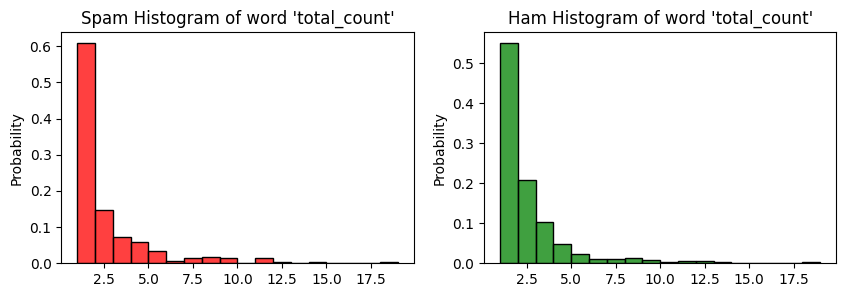

In [76]:
plt.figure(figsize=(10, 3))

plt.subplot(1, 2, 1)
sns.histplot(spam_words_count["was"], color="red", stat="probability", bins=np.arange(1, 20))
plt.title(f"Spam Histogram of word '{word}'")
plt.xlabel("")

plt.subplot(1, 2, 2)
sns.histplot(ham_words_count["was"], color="green", stat="probability", bins=np.arange(1, 20))
plt.title(f"Ham Histogram of word '{word}'")
plt.xlabel("")

Text(0.5, 0, '')

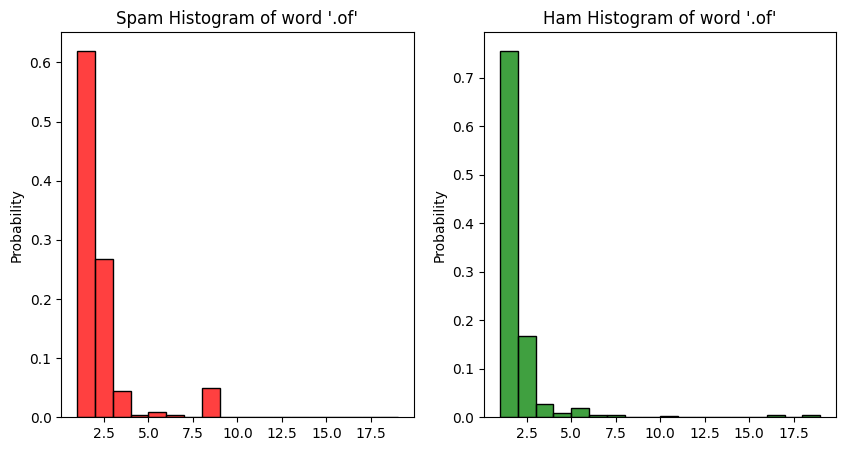

In [77]:
plt.figure(figsize=(10, 5))

word = ".of"

plt.subplot(1, 2, 1)
sns.histplot(spam_words_count[word], color="red", stat="probability", bins=np.arange(1, 20))
plt.title(f"Spam Histogram of word '{word}'")
plt.xlabel("")

plt.subplot(1, 2, 2)
sns.histplot(ham_words_count[word], color="green", stat="probability", bins=np.arange(1, 20))
plt.title(f"Ham Histogram of word '{word}'")
plt.xlabel("")

Text(0.5, 0, '')

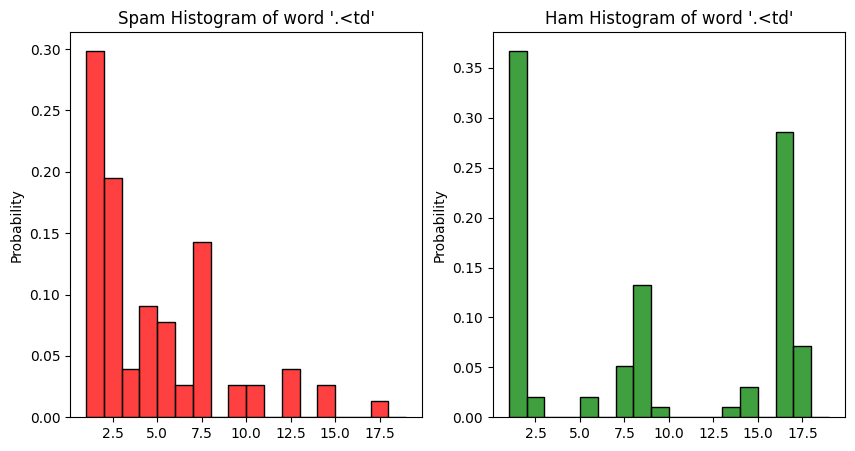

In [78]:
plt.figure(figsize=(10, 5))

word = ".<td"

plt.subplot(1, 2, 1)
sns.histplot(spam_words_count[word], color="red", stat="probability", bins=np.arange(1, 20))
plt.title(f"Spam Histogram of word '{word}'")
plt.xlabel("")

plt.subplot(1, 2, 2)
sns.histplot(ham_words_count[word], color="green", stat="probability", bins=np.arange(1, 20))
plt.title(f"Ham Histogram of word '{word}'")
plt.xlabel("")

Text(0.5, 0, '')

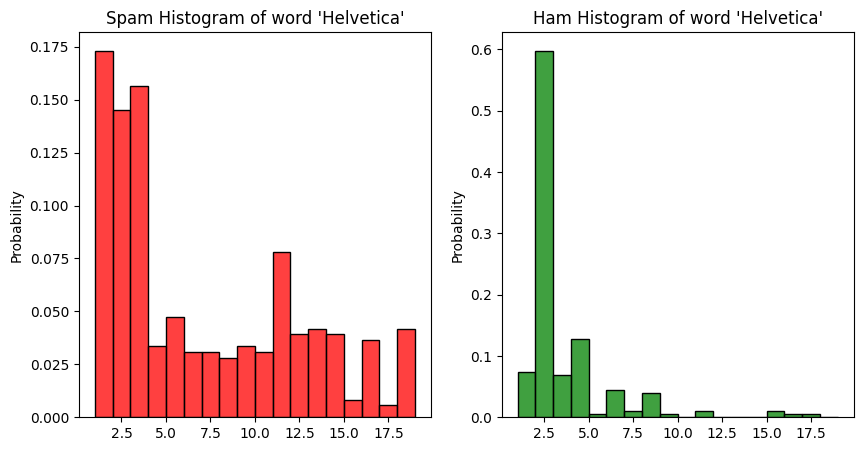

In [79]:
plt.figure(figsize=(10, 5))

word = "Helvetica"

plt.subplot(1, 2, 1)
sns.histplot(spam_words_count[word], color="red", stat="probability", bins=np.arange(1, 20))
plt.title(f"Spam Histogram of word '{word}'")
plt.xlabel("")

plt.subplot(1, 2, 2)
sns.histplot(ham_words_count[word], color="green", stat="probability", bins=np.arange(1, 20))
plt.title(f"Ham Histogram of word '{word}'")
plt.xlabel("")

Text(0.5, 0, '')

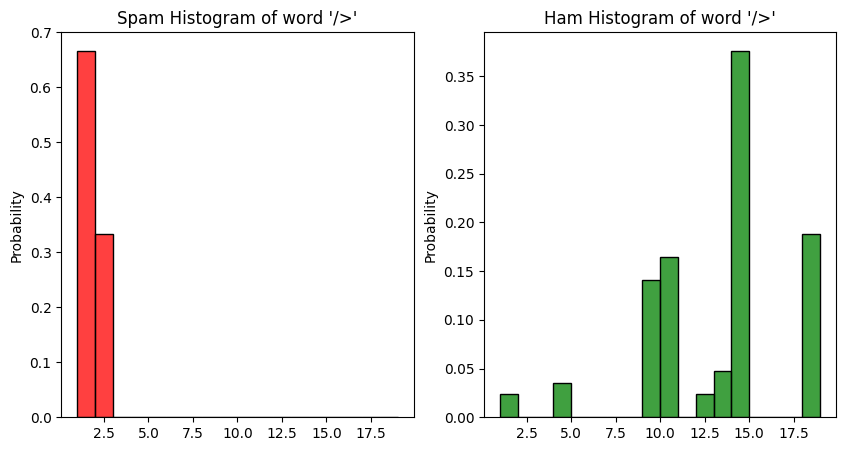

In [80]:
plt.figure(figsize=(10, 5))

word = "/>"

plt.subplot(1, 2, 1)
sns.histplot(spam_words_count[word], color="red", stat="probability", bins=np.arange(1, 20))
plt.title(f"Spam Histogram of word '{word}'")
plt.xlabel("")

plt.subplot(1, 2, 2)
sns.histplot(ham_words_count[word], color="green", stat="probability", bins=np.arange(1, 20))
plt.title(f"Ham Histogram of word '{word}'")
plt.xlabel("")

Text(0.5, 0, '')

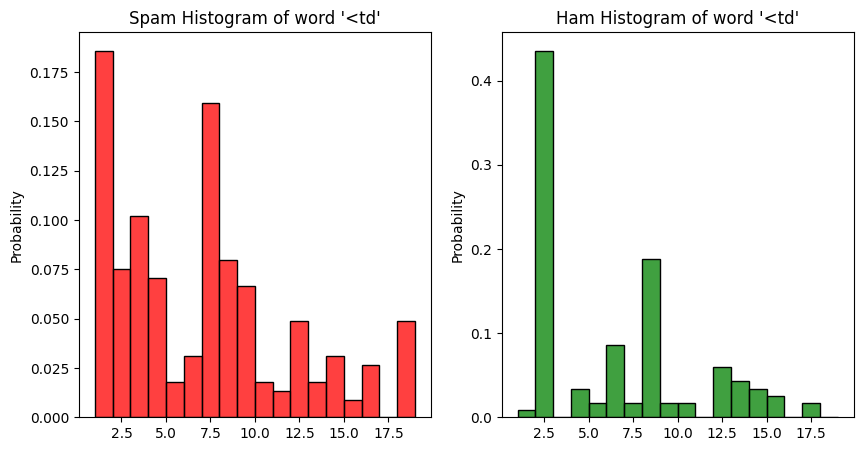

In [81]:
plt.figure(figsize=(10, 5))

word = "<td"

plt.subplot(1, 2, 1)
sns.histplot(spam_words_count[word], color="red", stat="probability", bins=np.arange(1, 20))
plt.title(f"Spam Histogram of word '{word}'")
plt.xlabel("")

plt.subplot(1, 2, 2)
sns.histplot(ham_words_count[word], color="green", stat="probability", bins=np.arange(1, 20))
plt.title(f"Ham Histogram of word '{word}'")
plt.xlabel("")

we can tell, there's no huge difference between spam and ham, lets focus on word's where difference can be noticed

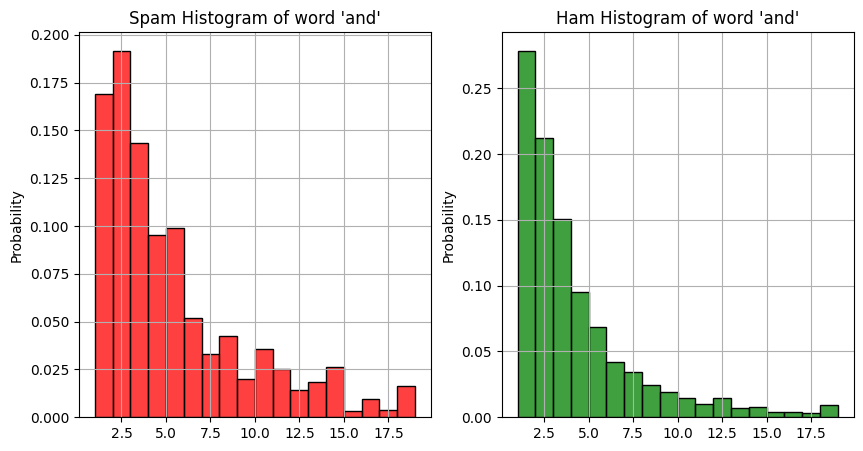

In [82]:
plt.figure(figsize=(10, 5))

word = "and"


plt.subplot(1, 2, 1)
sns.histplot(spam_words_count[word], color="red", stat="probability", bins=np.arange(1, 20))
plt.title(f"Spam Histogram of word '{word}'")
plt.xlabel("")
plt.grid("on")


plt.subplot(1, 2, 2)
sns.histplot(ham_words_count[word], color="green", stat="probability", bins=np.arange(1, 20))
plt.title(f"Ham Histogram of word '{word}'")
plt.xlabel("")
plt.grid("on")


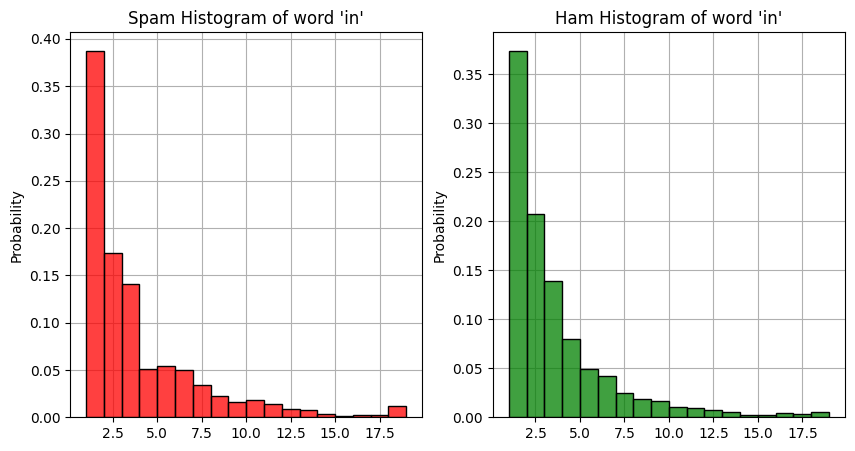

In [83]:
plt.figure(figsize=(10, 5))

word = "in"


plt.subplot(1, 2, 1)
sns.histplot(spam_words_count[word], color="red", stat="probability", bins=np.arange(1, 20), zorder=20)
plt.title(f"Spam Histogram of word '{word}'")
plt.xlabel("")
plt.grid("on", zorder=1)


plt.subplot(1, 2, 2)
sns.histplot(ham_words_count[word], color="green", stat="probability", bins=np.arange(1, 20), zorder=20)
plt.title(f"Ham Histogram of word '{word}'")
plt.xlabel("")
plt.grid("on", zorder=1)


Still, there's no signifficant difference, let's have our last try on number of words cointaining "<" or ">"

In [88]:
s = "., .>, 2002, the, from, with, .Received:, +0100, a, for, id, by, ESMTP, Linux, you, to, [127.0.0.1], I, it, -0000, Microsoft, my, that, have, [127.0.0.1]), localhost, on, SMTP, be, (Postfix), (localhost, .Delivered-To:, (single-drop);, (fetchmail-5.9.0), IMAP, phobos, (IST), (8.11.6/8.11.6), dogma.slashnull.org, .X-Priority:, 7bit, .Content-Transfer-Encoding:, .Content-Type:, text/plain;, 1.0, .MIME-Version:, .Date:, .Errors-To:, will, of, .X-Beenthere:,  .X-Mailman-Version:, bulk, .List-Id:, .Precedence:, .Sender:, and, your, can, or, --, <jm@localhost>;, jalapeno, jm@localhost, (jalapeno, this, but, #1, -0700, than, was, email, fork-admin@xent.com, xent.com, (PDT), his, e-mail, had, .Reply-To:, our, <a, .<table, We, />, .<td, Helvetica"

In [89]:
s=s.replace(" ", "").split(",")
s = [w for w in s if w]

In [90]:
len(s)

86



In [93]:
i = 0
counter=0
plt.figure(figsize=(10, 8*40))
for word in s:
    counter += 1
    plt.subplot(len(s), 2, counter)
    x = spam_words_count[word].sort_values(ascending=True)
    x = x[:int(0.95*x.shape[0])]
    sns.histplot(x, color="red", stat="probability", zorder=2)
    plt.title(f"Spam Histogram of word '{word}'")
    plt.xlabel("")
    plt.grid("on", zorder=1)

    counter += 1
    plt.subplot(len(s), 2, counter)
    x = ham_words_count[word].sort_values(ascending=True)
    x = x[:int(0.95*x.shape[0])]
    sns.histplot(x, color="green", stat="probability", zorder=2)
    plt.title(f"Ham Histogram of word '{word}'")
    plt.xlabel("")
    plt.grid("on", zorder=1)

In [94]:
counter

172

In [95]:
word

'Helvetica'

In [96]:
[s for s in important_words if "fetch" in s]

['(fetchmail-5.9.0)']

In [97]:
[c for c in ham_words_count.columns if "by" in c.lower()]

['by', '.\tby', 'By']

In [98]:
[c for c in ham_words_count.columns if c.lower().endswith("for")]

['for', '.\tfor', 'For']

In [99]:
x_ham = ham_words_count.loc[:, [c for c in ham_words_count.columns if "by" in c.lower()]]

In [100]:
x_spam = spam_words_count.loc[:, [c for c in ham_words_count.columns if "by" in c.lower()]]

In [101]:
x_ham.to_numpy().sum(axis=1)

array([7., 3., 8., ..., 8., 7., 3.])

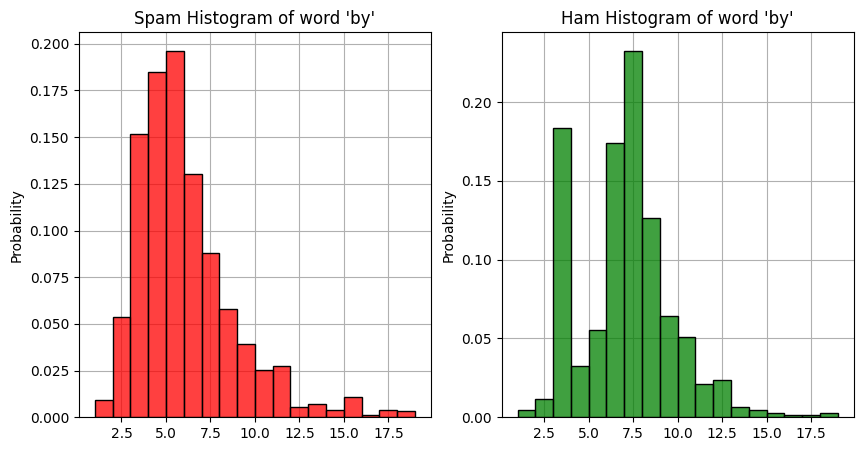

In [102]:
plt.figure(figsize=(10, 5))

word = "by"


plt.subplot(1, 2, 1)
sns.histplot(x_spam.to_numpy().sum(axis=1), color="red", stat="probability", bins=np.arange(1, 20), zorder=20)
plt.title(f"Spam Histogram of word '{word}'")
plt.xlabel("")
plt.grid("on", zorder=1)


plt.subplot(1, 2, 2)
sns.histplot(x_ham.to_numpy().sum(axis=1), color="green", stat="probability", bins=np.arange(1, 20), zorder=20)
plt.title(f"Ham Histogram of word '{word}'")
plt.xlabel("")
plt.grid("on", zorder=1)


In [103]:
x_ham = ham_words_count.loc[:, [c for c in ham_words_count.columns if c.lower().endswith("for")]]
x_spam = spam_words_count.loc[:, [c for c in ham_words_count.columns if c.lower().endswith("for")]]

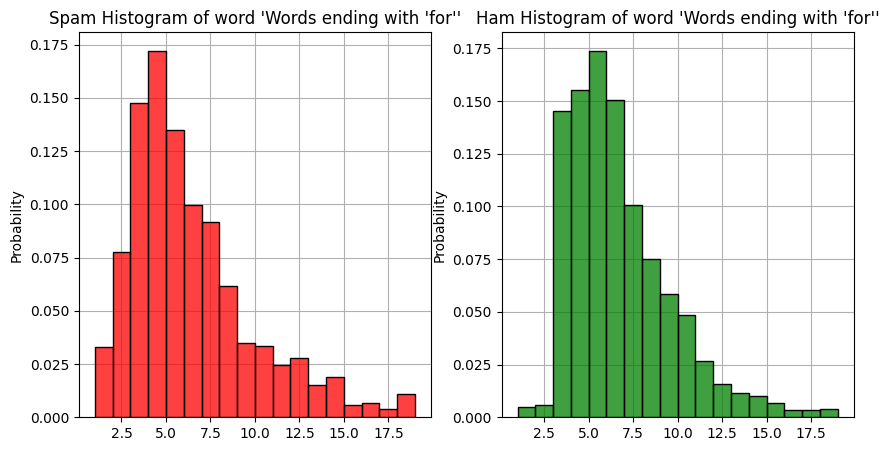

In [104]:
plt.figure(figsize=(10, 5))

word = "Words ending with 'for'"


plt.subplot(1, 2, 1)
sns.histplot(x_spam.to_numpy().sum(axis=1), color="red", stat="probability", bins=np.arange(1, 20), zorder=20)
plt.title(f"Spam Histogram of word '{word}'")
plt.xlabel("")
plt.grid("on", zorder=1)


plt.subplot(1, 2, 2)
sns.histplot(x_ham.to_numpy().sum(axis=1), color="green", stat="probability", bins=np.arange(1, 20), zorder=20)
plt.title(f"Ham Histogram of word '{word}'")
plt.xlabel("")
plt.grid("on", zorder=1)


OL, now we see, there're about 60 important words which have different distributions in to spam and ham

In [111]:
s = "., .>, 2002, the, from, with, .Received:, +0100, a, for, id, by, ESMTP, Linux, you, to, [127.0.0.1], I, it, -0000, Microsoft, my, that, have, [127.0.0.1]), localhost, on, SMTP, be, (Postfix), (localhost, .Delivered-To:, (single-drop);, (fetchmail-5.9.0), IMAP, phobos, (IST), (8.11.6/8.11.6), dogma.slashnull.org, .X-Priority:, 7bit, .Content-Transfer-Encoding:, .Content-Type:, text/plain;, 1.0, .MIME-Version:, .Date:, .Errors-To:, will, of, .X-Beenthere:,  .X-Mailman-Version:, bulk, .List-Id:, .Precedence:, .Sender:, and, your, can, or, --, <jm@localhost>;, jalapeno, jm@localhost, (jalapeno, this, but, #1, -0700, than, was, email, fork-admin@xent.com, xent.com, (PDT), his, e-mail, had, .Reply-To:, our, <a, .<table, We, />, .<td, Helvetica"
important_words = s.replace(" ", "").split(",")
important_words = [w for w in important_words if w]
important_words

['.',
 '.>',
 '2002',
 'the',
 'from',
 'with',
 '.Received:',
 '+0100',
 'a',
 'for',
 'id',
 'by',
 'ESMTP',
 'Linux',
 'you',
 'to',
 '[127.0.0.1]',
 'I',
 'it',
 '-0000',
 'Microsoft',
 'my',
 'that',
 'have',
 '[127.0.0.1])',
 'localhost',
 'on',
 'SMTP',
 'be',
 '(Postfix)',
 '(localhost',
 '.Delivered-To:',
 '(single-drop);',
 '(fetchmail-5.9.0)',
 'IMAP',
 'phobos',
 '(IST)',
 '(8.11.6/8.11.6)',
 'dogma.slashnull.org',
 '.X-Priority:',
 '7bit',
 '.Content-Transfer-Encoding:',
 '.Content-Type:',
 'text/plain;',
 '1.0',
 '.MIME-Version:',
 '.Date:',
 '.Errors-To:',
 'will',
 'of',
 '.X-Beenthere:',
 '.X-Mailman-Version:',
 'bulk',
 '.List-Id:',
 '.Precedence:',
 '.Sender:',
 'and',
 'your',
 'can',
 'or',
 '--',
 '<jm@localhost>;',
 'jalapeno',
 'jm@localhost',
 '(jalapeno',
 'this',
 'but',
 '#1',
 '-0700',
 'than',
 'was',
 'email',
 'fork-admin@xent.com',
 'xent.com',
 '(PDT)',
 'his',
 'e-mail',
 'had',
 '.Reply-To:',
 'our',
 '<a',
 '.<table',
 'We',
 '/>',
 '.<td',
 'Helvet

In [112]:
with open("data/train.pkl", "rb") as file:
    X_train = pickle.load(file)

In [113]:
counts = []
for index, row in X_train.iterrows():
    x = pd.Series(row["Message"].split(" "))
    x = x[x != ""]
    counts.append(
        ((x.str.find("<") >= 0) | (x.str.find(">") >= 0)).to_numpy().sum()
    )

In [114]:
X_train["<>_count"] = pd.Series(counts)

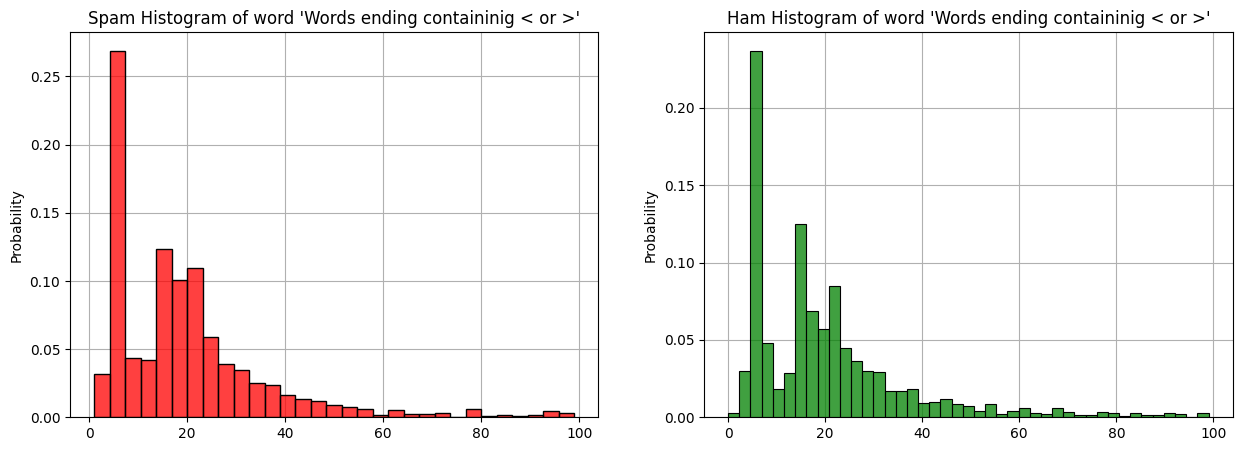

In [115]:
x_spam = X_train["<>_count"][X_train["Status"] == 2]
x_ham = X_train["<>_count"][X_train["Status"] < 2]

x_spam = x_spam[x_spam < 100]
x_ham = x_ham[x_ham < 100]

plt.figure(figsize=(15, 5))

word = "Words ending containinig < or >"


plt.subplot(1, 2, 1)
spam = sns.histplot(x_spam, color="red", stat="probability", zorder=20)
plt.title(f"Spam Histogram of word '{word}'")
plt.xlabel("")
plt.grid("on", zorder=1)


plt.subplot(1, 2, 2)
ham = sns.histplot(x_ham, color="green", stat="probability", zorder=20)
plt.title(f"Ham Histogram of word '{word}'")
plt.xlabel("")
plt.grid("on", zorder=1)
